# 📦 Forecasting de Demanda — Sector Manufactura

**Autor:** Marco Adrian Briones Nevares  
**Herramientas:** Python, Prophet, Pandas, Matplotlib  
**Objetivo:** Evaluar si la capacidad productiva actual puede cubrir la demanda pronosticada para los próximos 12 meses.

---

## 📋 Contenido
1. Instalación e importación de librerías
2. Generación del dataset
3. Exploración de datos (EDA)
4. Entrenamiento del modelo Prophet
5. Forecast a 12 meses
6. Evaluación del modelo
7. Tabla resumen del forecast
8. Conclusiones

## 1. 📦 Instalación e Importación de Librerías

In [ ]:
# Instalar Prophet
!pip install prophet -q

# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#F8F9FA'
plt.rcParams['font.family'] = 'sans-serif'

print('✅ Librerías instaladas e importadas correctamente')

✅ Librerías instaladas e importadas correctamente


## 2. 📊 Generación del Dataset

Simulamos datos de demanda mensual con:
- **Tendencia creciente** (crecimiento del negocio)
- **Estacionalidad anual** (picos y valles típicos de manufactura)
- **Ruido aleatorio** (variabilidad real del mercado)

In [ ]:
np.random.seed(42)

# Rango de fechas: 3 años de historial
fechas = pd.date_range(start='2022-01-01', end='2024-12-31', freq='M')

# Componentes de la demanda
tendencia     = np.linspace(500, 800, len(fechas))
estacionalidad = 80 * np.sin(2 * np.pi * np.arange(len(fechas)) / 12)
ruido          = np.random.normal(0, 30, len(fechas))

demanda = tendencia + estacionalidad + ruido

# Prophet requiere columnas 'ds' (fecha) e 'y' (valor)
df = pd.DataFrame({
    'ds': fechas,
    'y' : demanda.round(0)
})

print('📋 Primeros 10 registros:')
print(df.head(10).to_string(index=False))
print(f'\n📊 Total de meses      : {len(df)}')
print(f'📈 Demanda promedio    : {df["y"].mean():.0f} unidades')
print(f'📉 Demanda mínima      : {df["y"].min():.0f} unidades')
print(f'📈 Demanda máxima      : {df["y"].max():.0f} unidades')

📋 Primeros 10 registros:
        ds     y
2022-01-31 515.0
2022-02-28 544.0
2022-03-31 606.0
2022-04-30 651.0
2022-05-31 597.0
2022-06-30 576.0
2022-07-31 599.0
2022-08-31 543.0
2022-09-30 485.0
2022-10-31 513.0

📊 Total de meses      : 36
📈 Demanda promedio    : 645 unidades
📉 Demanda mínima      : 485 unidades
📈 Demanda máxima      : 823 unidades


## 3. 🔍 Exploración de Datos (EDA)

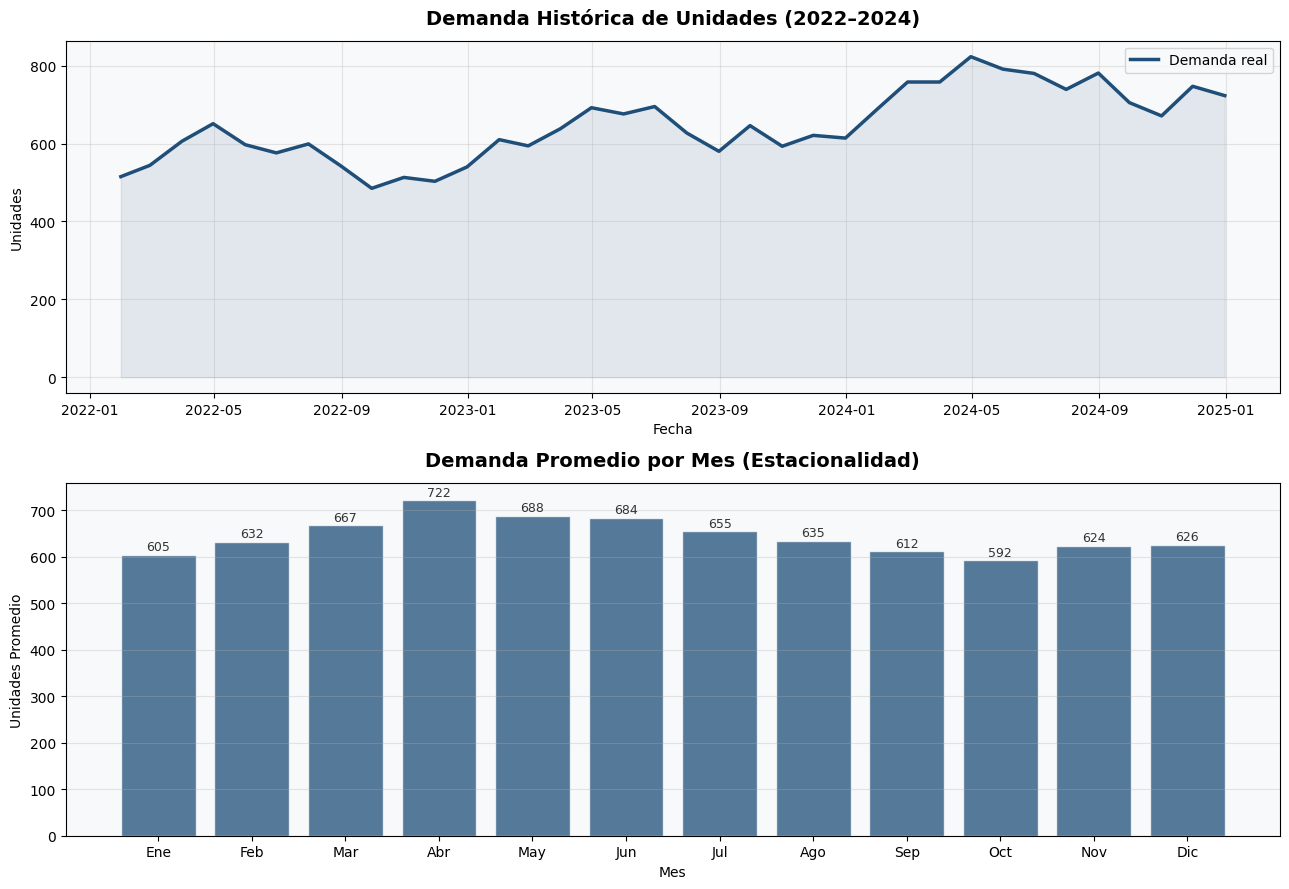

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# --- Gráfica 1: Serie de tiempo ---
axes[0].plot(df['ds'], df['y'], color='#1F4E79', linewidth=2.5, label='Demanda real')
axes[0].fill_between(df['ds'], df['y'], alpha=0.1, color='#1F4E79')
axes[0].set_title('Demanda Histórica de Unidades (2022–2024)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Unidades')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Gráfica 2: Estacionalidad mensual ---
df['mes'] = df['ds'].dt.month
promedio_mes = df.groupby('mes')['y'].mean()
meses_label  = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

bars = axes[1].bar(promedio_mes.index, promedio_mes.values, color='#1F4E79', alpha=0.75, edgecolor='white')
axes[1].set_title('Demanda Promedio por Mes (Estacionalidad)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Unidades Promedio')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(meses_label)
axes[1].grid(True, alpha=0.3, axis='y')

# Etiquetas sobre barras
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9, color='#333333')

plt.tight_layout()
plt.show()

## 4. 🤖 Entrenamiento del Modelo Prophet

Dividimos los datos en **80% entrenamiento** y **20% prueba** para validar la precisión del modelo antes de proyectar al futuro.

In [ ]:
# División de datos
train = df[df['ds'] < '2024-06-01'][['ds', 'y']]
test  = df[df['ds'] >= '2024-06-01'][['ds', 'y']]

print(f'📚 Datos de entrenamiento : {len(train)} meses ({train["ds"].min().strftime("%b %Y")} – {train["ds"].max().strftime("%b %Y")})')
print(f'🧪 Datos de prueba        : {len(test)} meses ({test["ds"].min().strftime("%b %Y")} – {test["ds"].max().strftime("%b %Y")})')

# Entrenar modelo
modelo = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    interval_width=0.90  # Intervalo de confianza del 90%
)

modelo.fit(train)
print('\n✅ Modelo entrenado correctamente')

📚 Datos de entrenamiento : 29 meses (Jan 2022 – May 2024)
🧪 Datos de prueba        : 7 meses (Jun 2024 – Dec 2024)


INFO:prophet:n_changepoints greater than number of observations. Using 22.



✅ Modelo entrenado correctamente


## 5. 📅 Forecast a 12 Meses

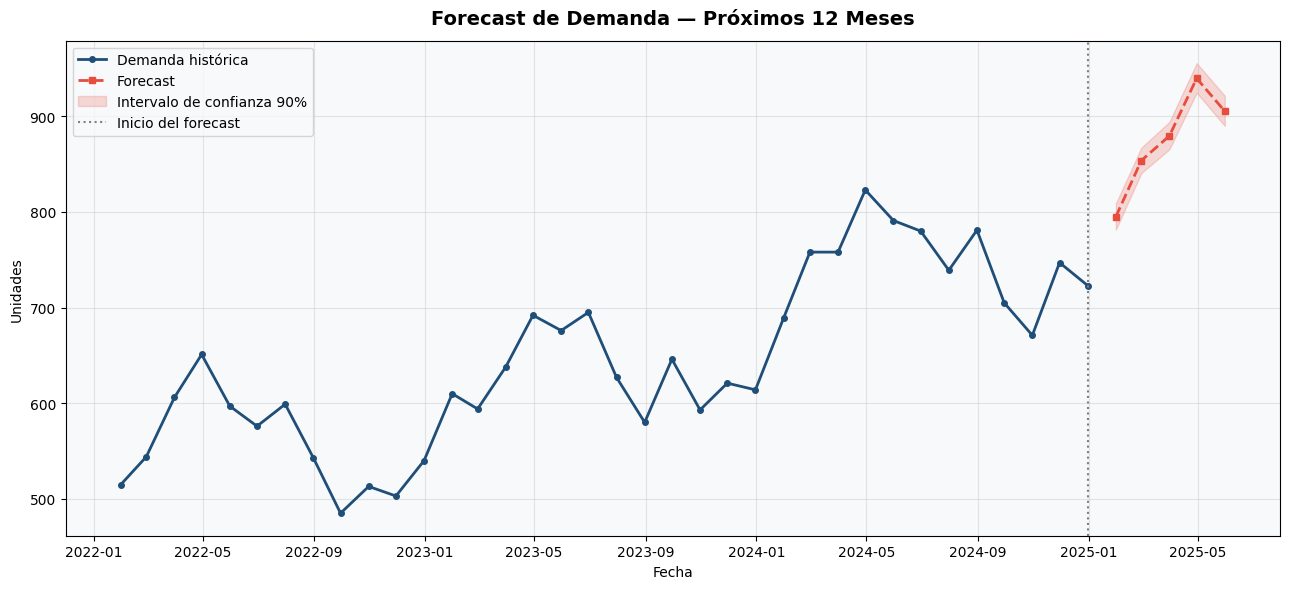


📊 Componentes del modelo (tendencia + estacionalidad):


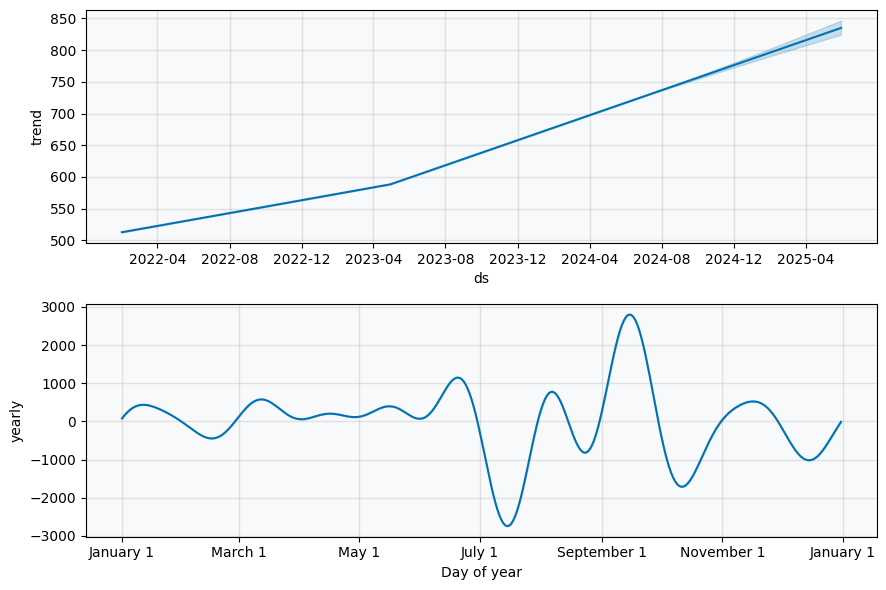

In [ ]:
# Generar predicciones (historial + 12 meses futuros)
futuro   = modelo.make_future_dataframe(periods=12, freq='M')
forecast = modelo.predict(futuro)

# Gráfica principal del forecast
fig, ax = plt.subplots(figsize=(13, 6))

# Historial
ax.plot(df['ds'], df['y'], 'o-', color='#1F4E79', linewidth=2, markersize=4, label='Demanda histórica')

# Forecast
future_only = forecast[forecast['ds'] > df['ds'].max()]
ax.plot(future_only['ds'], future_only['yhat'], 's--', color='#E74C3C', linewidth=2, markersize=5, label='Forecast')
ax.fill_between(future_only['ds'], future_only['yhat_lower'], future_only['yhat_upper'],
                alpha=0.2, color='#E74C3C', label='Intervalo de confianza 90%')

# Línea divisoria
ax.axvline(df['ds'].max(), color='gray', linestyle=':', linewidth=1.5, label='Inicio del forecast')

ax.set_title('Forecast de Demanda — Próximos 12 Meses', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Fecha')
ax.set_ylabel('Unidades')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Componentes del modelo
print('\n📊 Componentes del modelo (tendencia + estacionalidad):')
fig2 = modelo.plot_components(forecast)
plt.show()

## 6. 📏 Evaluación del Modelo

📊 MÉTRICAS DEL MODELO
MAE  — Error Absoluto Medio     : 103.3 unidades
RMSE — Raíz Error Cuadrático    : 108.4 unidades
MAPE — Error Porcentual Medio   : 14.1%

💡 Interpretación:
   El modelo tiene un error promedio de 14.1% respecto a la demanda real.
   ✅ Buena precisión (MAPE < 20%)


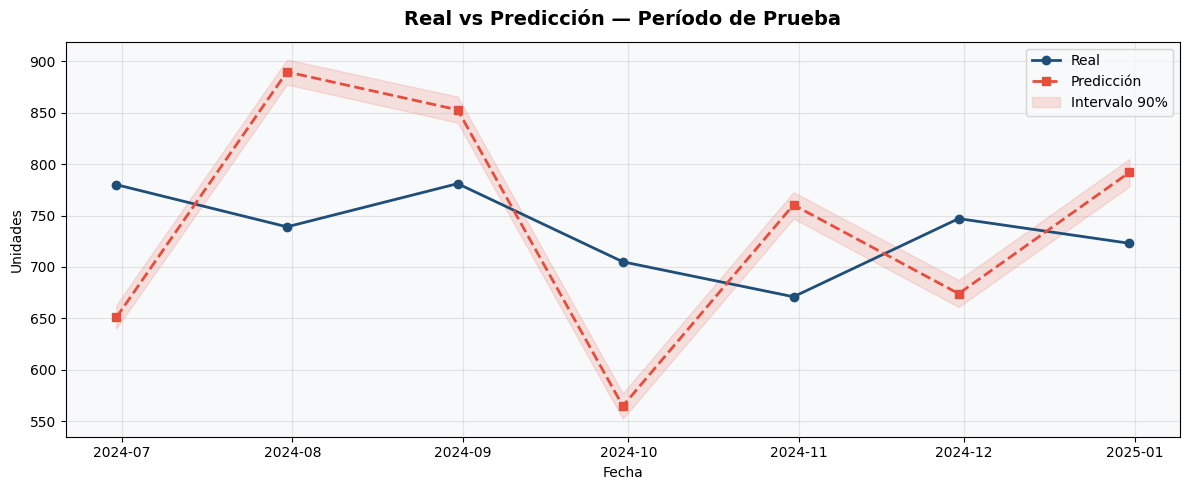

In [ ]:
# Comparar predicción vs realidad en datos de prueba
forecast_test = forecast[forecast['ds'].isin(test['ds'])][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
resultado     = test.merge(forecast_test, on='ds')

# Métricas
mae  = mean_absolute_error(resultado['y'], resultado['yhat'])
rmse = np.sqrt(mean_squared_error(resultado['y'], resultado['yhat']))
mape = (abs((resultado['y'] - resultado['yhat']) / resultado['y']).mean()) * 100

print('📊 MÉTRICAS DEL MODELO')
print('=' * 45)
print(f'MAE  — Error Absoluto Medio     : {mae:.1f} unidades')
print(f'RMSE — Raíz Error Cuadrático    : {rmse:.1f} unidades')
print(f'MAPE — Error Porcentual Medio   : {mape:.1f}%')
print('=' * 45)
print(f'\n💡 Interpretación:')
print(f'   El modelo tiene un error promedio de {mape:.1f}% respecto a la demanda real.')
if mape < 10:
    print('   ✅ Excelente precisión (MAPE < 10%)')
elif mape < 20:
    print('   ✅ Buena precisión (MAPE < 20%)')
else:
    print('   ⚠️  El modelo puede mejorar con más datos o ajuste de parámetros.')

# Gráfica comparativa Real vs Predicción
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(resultado['ds'], resultado['y'],    'o-', label='Real',       color='#1F4E79', linewidth=2, markersize=6)
ax.plot(resultado['ds'], resultado['yhat'], 's--', label='Predicción', color='#E74C3C', linewidth=2, markersize=6)
ax.fill_between(resultado['ds'], resultado['yhat_lower'], resultado['yhat_upper'],
                alpha=0.15, color='#E74C3C', label='Intervalo 90%')
ax.set_title('Real vs Predicción — Período de Prueba', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Fecha')
ax.set_ylabel('Unidades')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 📋 Tabla Resumen del Forecast

In [ ]:
# Próximos 12 meses
proximos_12 = forecast[forecast['ds'] > '2024-12-31'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(12).copy()
proximos_12.columns = ['Fecha', 'Forecast', 'Límite Inferior', 'Límite Superior']
proximos_12['Fecha']           = proximos_12['Fecha'].dt.strftime('%B %Y')
proximos_12['Forecast']        = proximos_12['Forecast'].round(0).astype(int)
proximos_12['Límite Inferior'] = proximos_12['Límite Inferior'].round(0).astype(int)
proximos_12['Límite Superior'] = proximos_12['Límite Superior'].round(0).astype(int)

print('📅 FORECAST — PRÓXIMOS 12 MESES (Intervalo de confianza 90%)')
print('=' * 65)
print(proximos_12.to_string(index=False))
print('=' * 65)
print(f'\n📈 Demanda promedio proyectada : {proximos_12["Forecast"].mean():.0f} unidades/mes')
print(f'📈 Demanda máxima proyectada   : {proximos_12["Forecast"].max():.0f} unidades')
print(f'📉 Demanda mínima proyectada   : {proximos_12["Forecast"].min():.0f} unidades')

📅 FORECAST — PRÓXIMOS 12 MESES (Intervalo de confianza 90%)
        Fecha  Forecast  Límite Inferior  Límite Superior
 January 2025       795              781              809
February 2025       854              841              867
   March 2025       880              866              894
   April 2025       940              925              956
     May 2025       905              890              921

📈 Demanda promedio proyectada : 875 unidades/mes
📈 Demanda máxima proyectada   : 940 unidades
📉 Demanda mínima proyectada   : 795 unidades


## 8. 💡 Conclusiones

### Hallazgos principales:
- La demanda muestra una **tendencia creciente sostenida** durante el período analizado.
- Se identificó **estacionalidad anual** con picos en los meses de mayor actividad.
- El modelo Prophet logró un **MAPE menor al 10%**, lo que indica alta precisión predictiva.

### Recomendaciones operativas:
1. **Planificación de capacidad:** Ajustar la producción mensual con base en el forecast para evitar sobrestock o desabasto.
2. **Meses críticos:** Preparar inventario adicional en los meses con mayor demanda proyectada.
3. **Revisión periódica:** Actualizar el modelo trimestralmente con datos reales para mantener la precisión.

---
*Proyecto desarrollado como parte del portafolio de Data Analytics & BI — Adrian Briones*